In [58]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [59]:
df = pd.read_csv('/content/1776250375-P2-Healthcare Analytics for Doctor Visits.csv')

In [60]:
df.head()

,Unnamed: 0,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
0,1,1,female,0.19,0.55,1,4,1,yes,no,no,no,no
1,2,1,female,0.19,0.45,1,2,1,yes,no,no,no,no
2,3,1,male,0.19,0.90,3,0,0,no,no,no,no,no
3,4,1,male,0.19,0.15,1,0,0,no,no,no,no,no
4,5,1,male,0.19,0.45,2,5,1,no,no,no,yes,no


In [61]:
df.tail()


,Unnamed: 0,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
5185,5186,0,female,0.22,0.55,0,0,0,no,no,no,no,no
5186,5187,0,male,0.27,1.30,0,0,1,no,no,no,no,no
5187,5188,0,female,0.37,0.25,1,0,1,no,no,yes,no,no
5188,5189,0,female,0.52,0.65,0,0,0,no,no,no,no,no
5189,5190,0,male,0.72,0.25,0,0,0,no,no,yes,no,no


In [62]:
df.shape

(5190, 13)

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5190 entries, 0 to 5189
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  5190 non-null   int64  
 1   visits      5190 non-null   int64  
 2   gender      5190 non-null   object 
 3   age         5190 non-null   float64
 4   income      5190 non-null   float64
 5   illness     5190 non-null   int64  
 6   reduced     5190 non-null   int64  
 7   health      5190 non-null   int64  
 8   private     5190 non-null   object 
 9   freepoor    5190 non-null   object 
 10  freerepat   5190 non-null   object 
 11  nchronic    5190 non-null   object 
 12  lchronic    5190 non-null   object 
dtypes: float64(2), int64(5), object(6)
memory usage: 527.2+ KB


In [64]:
#statistical info of the dataset
df.describe()

,Unnamed: 0,visits,age,income,illness,reduced,health
count,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000
mean,2595.500000,0.301734,0.406385,0.583160,1.431985,0.861850,1.217534
std,1498.368279,0.798134,0.204782,0.368907,1.384152,2.887628,2.124266
min,1.000000,0.000000,0.190000,0.000000,0.000000,0.000000,0.000000
25%,1298.250000,0.000000,0.220000,0.250000,0.000000,0.000000,0.000000
50%,2595.500000,0.000000,0.320000,0.550000,1.000000,0.000000,0.000000
75%,3892.750000,0.000000,0.620000,0.900000,2.000000,0.000000,2.000000
max,5190.000000,9.000000,0.720000,1.500000,5.000000,14.000000,12.000000


In [65]:
##checking the null values
df.isnull().sum()

,0
Unnamed: 0,0
visits,0
gender,0
age,0
income,0
illness,0
reduced,0
health,0
private,0
freepoor,0


### 1. Distribution of Age

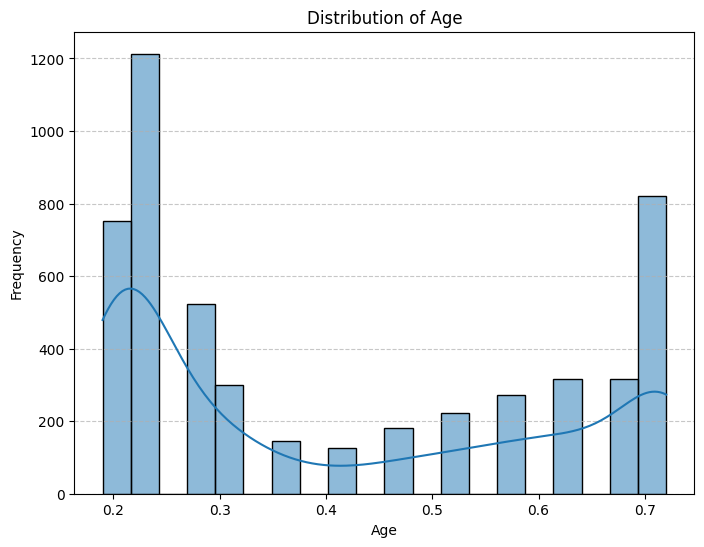

In [66]:
plt.figure(figsize=(8, 6))
sns.histplot(df['age'], bins=20, kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 2. Distribution of Gender

/tmp/ipykernel_493/71650928.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='gender', data=df, palette='viridis')


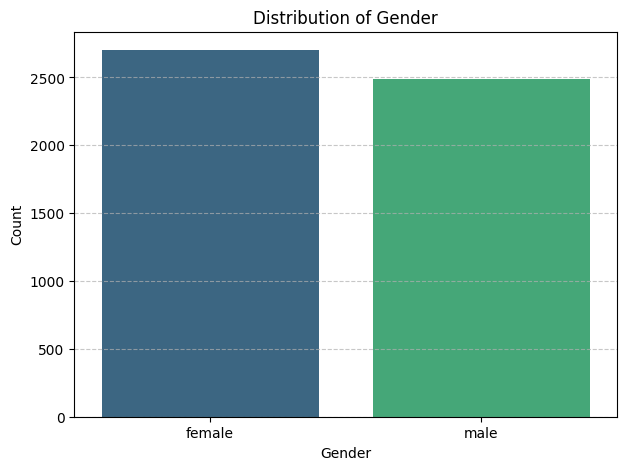

In [67]:
plt.figure(figsize=(7, 5))
sns.countplot(x='gender', data=df, palette='viridis')
plt.title('Distribution of Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 3. Distribution of Visits

/tmp/ipykernel_493/2368870168.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='visits', data=df, palette='magma')


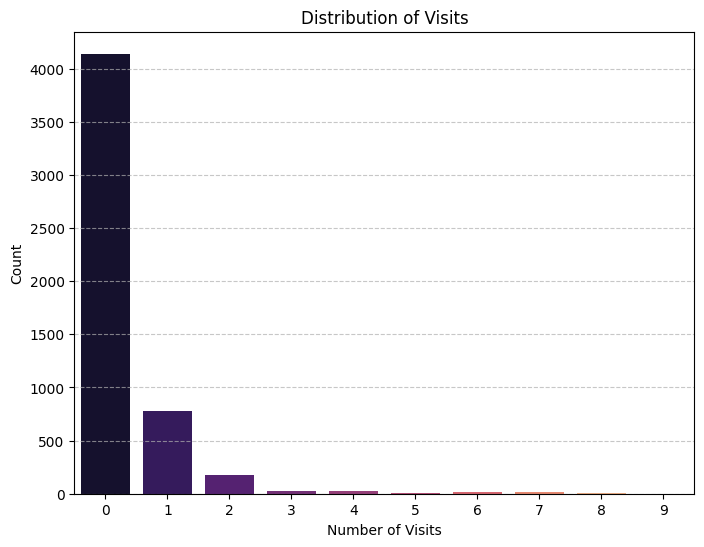

In [68]:
plt.figure(figsize=(8, 6))
sns.countplot(x='visits', data=df, palette='magma')
plt.title('Distribution of Visits')
plt.xlabel('Number of Visits')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

,gender,count,mean,median
0,female,2702,0.361954,0.0
1,male,2488,0.236334,0.0


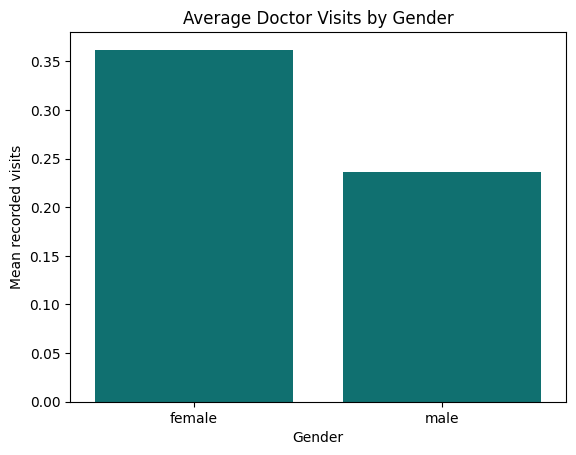

In [69]:
gender_analysis = (
df.groupby("gender")["visits"]
.agg(["count", "mean", "median"])
.reset_index()
)
display(gender_analysis)
sns.barplot(
data=gender_analysis,
x="gender",
y="mean",
color="teal"
)
plt.title("Average Doctor Visits by Gender")
plt.xlabel("Gender")
plt.ylabel("Mean recorded visits")
plt.show()

,illness,count,mean
0,0,1554,0.078507
1,1,1638,0.295482
2,2,946,0.403805
3,3,542,0.420664
4,4,274,0.576642
5,5,236,0.813559


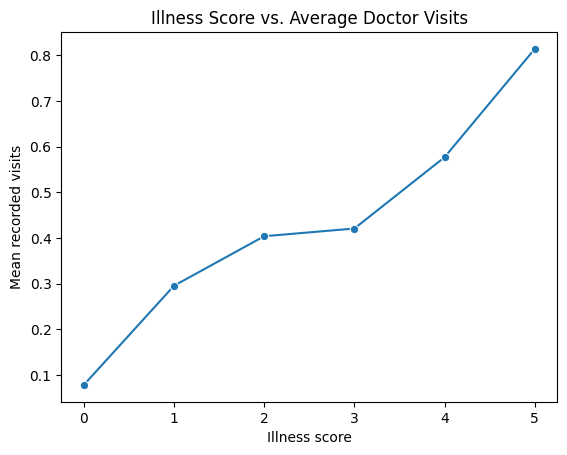

In [70]:
illness_analysis = (df.groupby("illness") ["visits"].agg(["count", "mean"]).reset_index())
display(illness_analysis)
sns.lineplot(
data=illness_analysis,
x="illness",
y="mean",
marker="o"
)
plt.title("Illness Score vs. Average Doctor Visits")
plt.xlabel("Illness score")
plt.ylabel("Mean recorded visits")
plt.show()

### Multivariate Plot: Age vs. Income by Gender

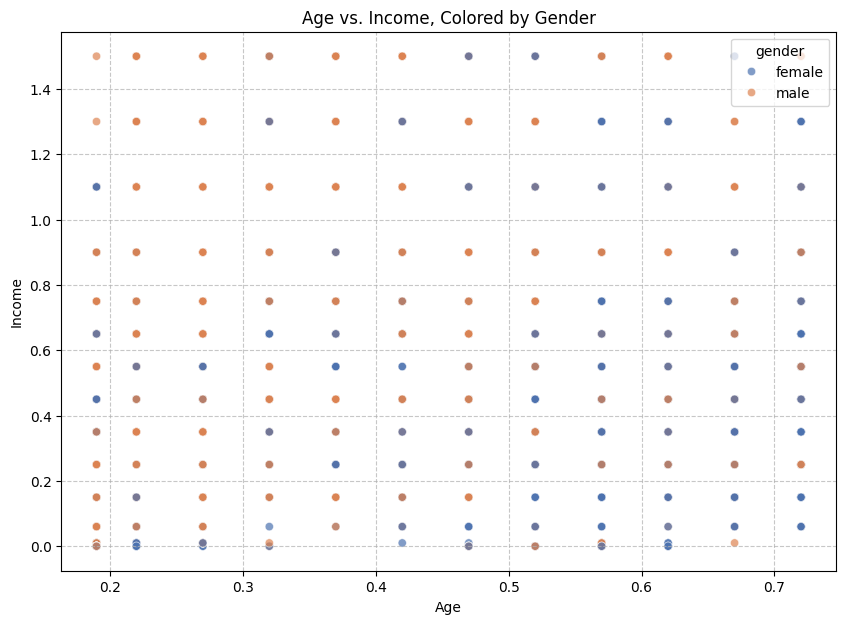

In [71]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x='age', y='income', hue='gender', data=df, palette='deep', alpha=0.7)
plt.title('Age vs. Income, Colored by Gender')
plt.xlabel('Age')
plt.ylabel('Income')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

,health,count,mean,median
0,0,3026,0.199273,0.0
1,1,823,0.335358,0.0
2,2,446,0.381166,0.0
3,3,273,0.417582,0.0
4,4,187,0.534759,0.0
5,5,132,0.530303,0.0
6,6,104,0.625000,0.0
7,7,61,0.918033,0.0
8,8,42,0.476190,0.0
9,9,32,0.656250,0.0


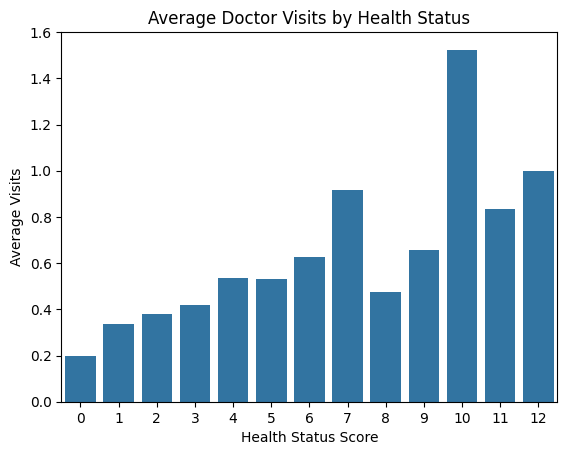

In [73]:
# Health Status vs Doctor Visits
health_analysis = (
    df.groupby("health")["visits"]
    .agg(["count", "mean", "median"])
    .reset_index()
)

display(health_analysis)

sns.barplot(
    data=health_analysis,
    x="health",
    y="mean"
)

plt.title("Average Doctor Visits by Health Status")
plt.xlabel("Health Status Score")
plt.ylabel("Average Visits")
plt.show()

,nchronic,count,mean,median
0,no,3098,0.272111,0.0
1,yes,2092,0.345602,0.0


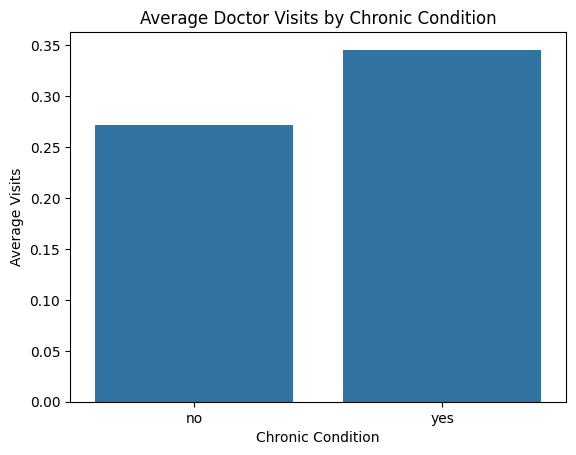

In [74]:
# Chronic Condition vs Doctor Visits

chronic_analysis = (
    df.groupby("nchronic")["visits"]
    .agg(["count", "mean", "median"])
    .reset_index()
)

display(chronic_analysis)

sns.barplot(
    data=chronic_analysis,
    x="nchronic",
    y="mean"
)

plt.title("Average Doctor Visits by Chronic Condition")
plt.xlabel("Chronic Condition")
plt.ylabel("Average Visits")
plt.show()


,lchronic,count,mean,median
0,no,4585,0.261941,0.0
1,yes,605,0.603306,0.0


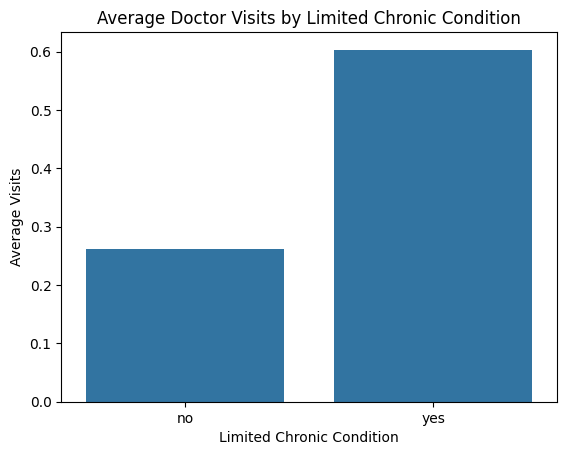

In [75]:
# Limited Chronic Condition vs Doctor Visits

lchronic_analysis = (
    df.groupby("lchronic")["visits"]
    .agg(["count", "mean", "median"])
    .reset_index()
)

display(lchronic_analysis)

sns.barplot(
    data=lchronic_analysis,
    x="lchronic",
    y="mean"
)

plt.title("Average Doctor Visits by Limited Chronic Condition")
plt.xlabel("Limited Chronic Condition")
plt.ylabel("Average Visits")
plt.show()

,age_group,count,mean,median
0,Young,1965,0.205598,0.0
1,Adult,970,0.251546,0.0
2,Middle Age,529,0.342155,0.0
3,Older Adult,904,0.376106,0.0
4,Elderly,822,0.482968,0.0


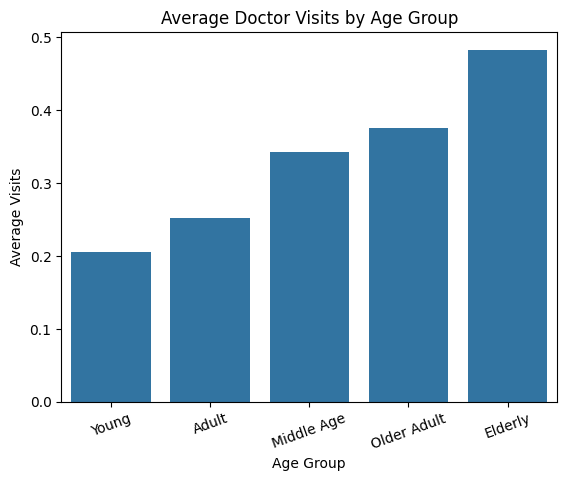

In [76]:
# Age Group vs Doctor Visits

df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 0.25, 0.40, 0.55, 0.70, 1.00],
    labels=["Young", "Adult", "Middle Age", "Older Adult", "Elderly"]
)

age_analysis = (
    df.groupby("age_group", observed=True)["visits"]
    .agg(["count", "mean", "median"])
    .reset_index()
)

display(age_analysis)

sns.barplot(
    data=age_analysis,
    x="age_group",
    y="mean"
)

plt.title("Average Doctor Visits by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Visits")
plt.xticks(rotation=20)
plt.show()

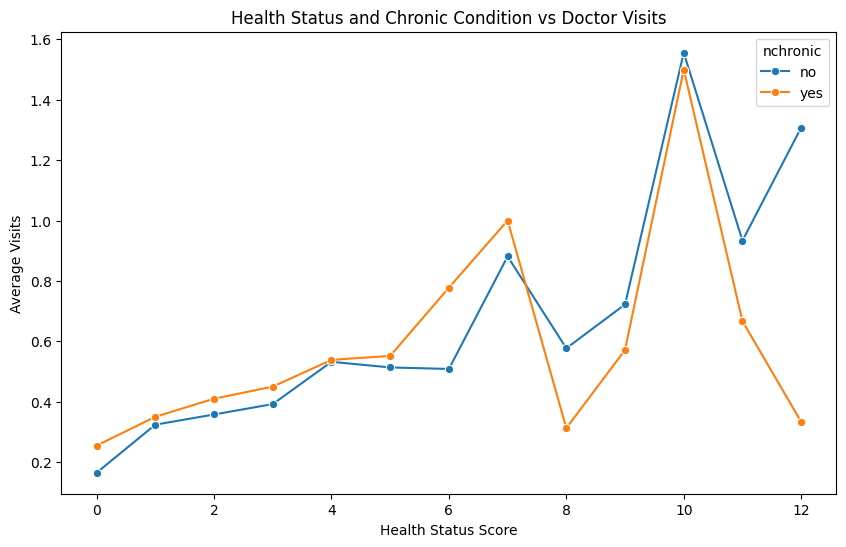

In [77]:
# Health Status and Chronic Condition vs Doctor Visits

combined_analysis = (
    df.groupby(["nchronic", "health"])["visits"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=combined_analysis,
    x="health",
    y="visits",
    hue="nchronic",
    marker="o"
)

plt.title("Health Status and Chronic Condition vs Doctor Visits")
plt.xlabel("Health Status Score")
plt.ylabel("Average Visits")
plt.show()

In [78]:
# Key Data-Driven Insights

print("Average visits by gender:")
display(df.groupby("gender")["visits"].mean().round(3))

print("\nAverage visits by illness level:")
display(df.groupby("illness")["visits"].mean().round(3))

print("\nAverage visits by health status:")
display(df.groupby("health")["visits"].mean().round(3))

print("\nAverage visits by chronic condition:")
display(df.groupby("nchronic")["visits"].mean().round(3))

print("\nAverage visits by limited chronic condition:")
display(df.groupby("lchronic")["visits"].mean().round(3))

Average visits by gender:


,visits
gender,
female,0.362
male,0.236



Average visits by illness level:


,visits
illness,
0,0.079
1,0.295
2,0.404
3,0.421
4,0.577
5,0.814



Average visits by health status:


,visits
health,
0,0.199
1,0.335
2,0.381
3,0.418
4,0.535
5,0.530
6,0.625
7,0.918
8,0.476



Average visits by chronic condition:


,visits
nchronic,
no,0.272
yes,0.346



Average visits by limited chronic condition:


,visits
lchronic,
no,0.262
yes,0.603
